GMMM in Python

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [3]:
data = load_iris()
X, y = data.data, data.target
target_names = data.target_names

In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

In [6]:
# ricerca del k ottimale usando il criterio di massima verosimiglianza

log_likelihoods = []
n_components = range(1, 11)

for k in n_components:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_pca)
    log_likelihoods.append(gmm.score(X_pca))

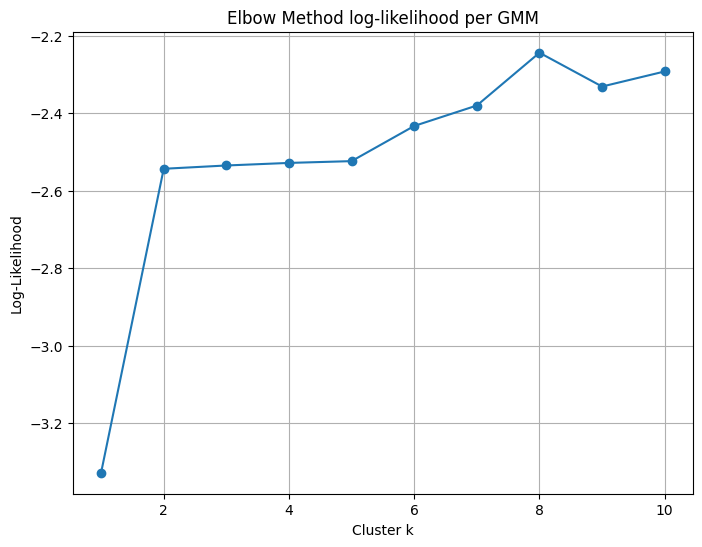

In [7]:
# fare grafico per vedere cosa è uscito
plt.figure(figsize=(8, 6))
plt.plot(n_components, log_likelihoods, marker='o')
plt.xlabel('Cluster k')
plt.ylabel('Log-Likelihood')
plt.title('Elbow Method log-likelihood per GMM')
plt.grid(True)
plt.show()

In [13]:
# scelta di k = 2 dal grafico
best_k = 2
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)

print(labels.shape)
print(labels)

(150,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


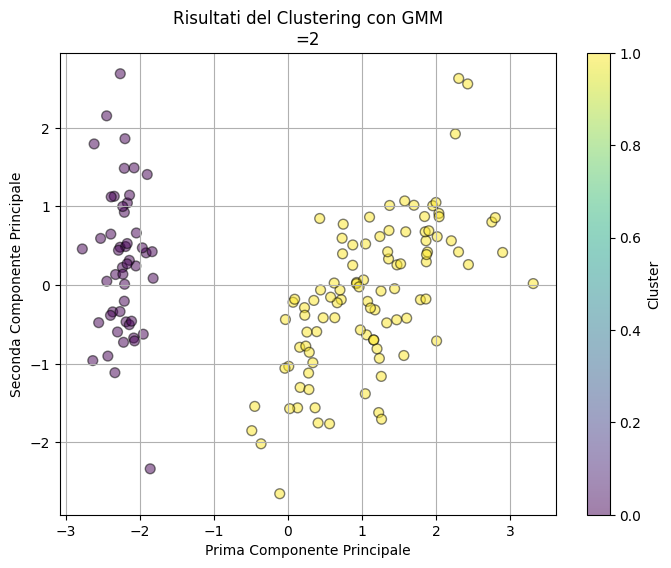

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50, alpha=0.5)
plt.xlabel('Prima Componente Principale')
plt.ylabel('Seconda Componente Principale')
plt.title(f'Risultati del Clustering con GMM\n={best_k}')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

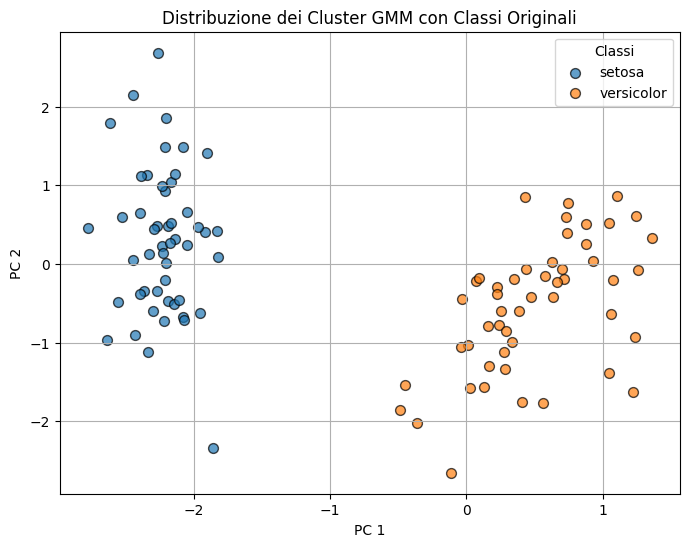

In [15]:
# vediamo come queste label sono state predette
plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    mask = (y == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=target_names[label], edgecolor='k', s=50, alpha=0.7)

plt.title('Distribuzione dei Cluster GMM con Classi Originali')
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Classi")
plt.grid(True)
plt.show()

In [16]:
# funzione per misurare accuracy

# il ciclo for è per riassegnare le etichette dopo la PCA, dato che GMM non sa nulla delle classi originali

def gmm_accuracy(y_true, y_pred):
    labels = np.zeros_like(y_pred)
    for cluster_id in np.unique(y_pred):
        mask = (y_pred == cluster_id)
        true_labels = y_true[mask]
        if len(true_labels) > 0:
            most_common = np.bincount(true_labels).argmax()
            labels[mask] = most_common
    return np.mean(labels == y_true)

In [17]:
accuracy = gmm_accuracy(y, labels)
print(f'Accuracy del GMM: {accuracy*100:.2f}%')

Accuracy del GMM: 66.67%
